## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from xSM_Potential import xSM

In [3]:
model = xSM(lH=0.13, muH=88.4, lHS=0.25, muHS=5.0,
            lS=0.3,  mu3=20.0, muS=60.0)

print("Model created successfully")
print(f"  g  = {model.g}")
print(f"  yt = {model.yt}")
print(f"  yb = {model.yb}")

Model created successfully
  g  = 0.6483
  yt = 0.9946
  yb = 0.0243


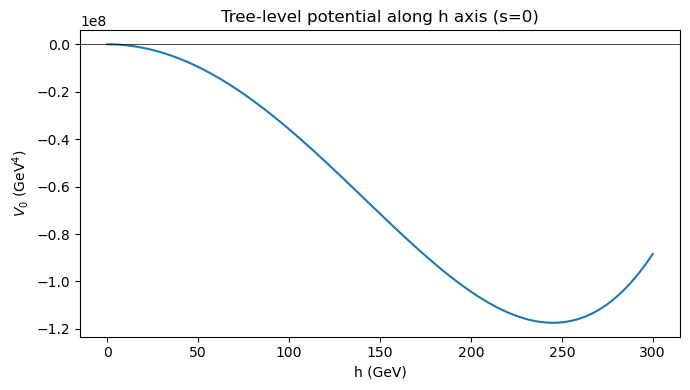

In [5]:
h_vals = np.linspace(0, 300, 500)
X = np.column_stack([h_vals, np.zeros_like(h_vals)])
V_vals = model.V0(X)

plt.figure(figsize=(7,4))
plt.plot(h_vals, V_vals)
plt.xlabel("h (GeV)")
plt.ylabel(r"$V_0$ (GeV$^4$)")
plt.title("Tree-level potential along h axis (s=0)")
plt.axhline(0, color='k', linewidth=0.5)
plt.tight_layout()
plt.show()

In [7]:
model.findAllTransitions()
print("Done!")

Tracing phase starting at x = [219.64184753 -35.94404034] ; t = 0.0
Tracing minimum up
traceMinimum t0 = 0
...............................................................................................................................................................................
Tracing phase starting at x = [ 4.15232094e-05 -4.69118751e+01] ; t = 144.93489755405972
Tracing minimum down
traceMinimum t0 = 144.935
......................
Tracing minimum up
traceMinimum t0 = 144.935
..........................................................
Tracing phase starting at x = [-5.57678394e-06  1.23065272e+02] ; t = 155.46883630272038
Tracing minimum down
traceMinimum t0 = 155.469
....................................
Tracing minimum up
traceMinimum t0 = 155.469
................................................................................................................................
Tracing phase starting at x = [ 70.85867981 122.79054003] ; t = 115.07330372651661
Tracing minimum down
tra

In [13]:
for i, trans in enumerate(model.TnTrans):
    Tc   = trans['Tnuc']
    high = trans['high_vev']
    low  = trans['low_vev']
    xi_c = abs(low[0] - high[0]) / Tc
    print(f"Transition {i}:  Tc = {Tc:.2f} GeV  |  xi_c = {xi_c:.4f}")

Transition 0:  Tc = 115.95 GeV  |  xi_c = 0.0000
Transition 1:  Tc = 115.45 GeV  |  xi_c = 0.8663


In [8]:
trans = model.TnTrans[1]
Tc    = trans['Tnuc']
high  = trans['high_vev']
low   = trans['low_vev']

# Polish the minima numerically
def Vtot_scalar(X, T):
    return model.Vtot(np.array([X]), T)[0]

res_high = minimize(Vtot_scalar, high, args=(Tc,), method='Nelder-Mead',
                    options={'xatol':1e-6, 'fatol':1e-6})
res_low  = minimize(Vtot_scalar, low,  args=(Tc,), method='Nelder-Mead',
                    options={'xatol':1e-6, 'fatol':1e-6})

high_min = res_high.x
low_min  = res_low.x
xi_c     = abs(low_min[0] - high_min[0]) / Tc

print(f"Tc     = {Tc:.2f} GeV")
print(f"high phase: (φ_h, φ_s) = ({high_min[0]:.2f}, {high_min[1]:.2f}) GeV")
print(f"low  phase: (φ_h, φ_s) = ({low_min[0]:.2f}, {low_min[1]:.2f}) GeV")
print(f"ξ_c    = {xi_c:.4f}")

Tc     = 115.45 GeV
high phase: (φ_h, φ_s) = (58.26, 127.18) GeV
low  phase: (φ_h, φ_s) = (158.27, -37.04) GeV
ξ_c    = 0.8663


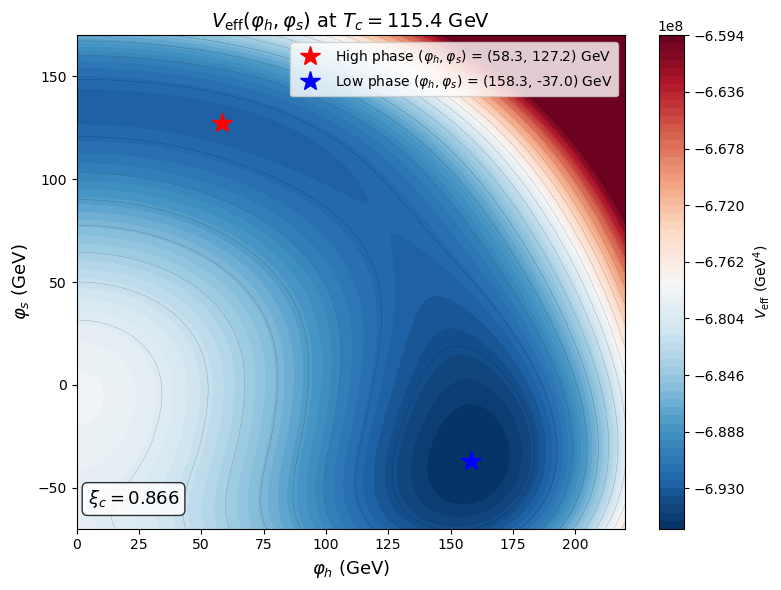

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))

# Grid in (h, s)
h_vals = np.linspace(0, 220, 300)
s_vals = np.linspace(-70, 170, 300)
H, S   = np.meshgrid(h_vals, s_vals)
X_grid = np.column_stack([H.ravel(), S.ravel()])
V_grid = model.Vtot(X_grid, Tc).reshape(H.shape)

# Clip for contrast
V_plot = np.clip(V_grid, np.percentile(V_grid, 2), np.percentile(V_grid, 95))

cp = ax.contourf(H, S, V_plot, levels=60, cmap='RdBu_r')
ax.contour(H, S, V_plot, levels=20, colors='k', linewidths=0.3, alpha=0.4)
plt.colorbar(cp, ax=ax, label=r'$V_{\rm eff}$ (GeV$^4$)')

# Mark polished minima
ax.plot(high_min[0], high_min[1], 'r*', markersize=15, zorder=5,
        label=rf'High phase $(\varphi_h, \varphi_s)$ = ({high_min[0]:.1f}, {high_min[1]:.1f}) GeV')
ax.plot(low_min[0],  low_min[1],  'b*', markersize=15, zorder=5,
        label=rf'Low phase $(\varphi_h, \varphi_s)$ = ({low_min[0]:.1f}, {low_min[1]:.1f}) GeV')

ax.set_xlabel(r'$\varphi_h$ (GeV)', fontsize=13)
ax.set_ylabel(r'$\varphi_s$ (GeV)', fontsize=13)
ax.set_title(rf'$V_{{\rm eff}}(\varphi_h, \varphi_s)$ at $T_c = {Tc:.1f}$ GeV', fontsize=14)
ax.legend(fontsize=10, loc='upper right')
ax.text(0.02, 0.05, rf'$\xi_c = {xi_c:.3f}$', transform=ax.transAxes,
        fontsize=13, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig("EWPT_contour.png", dpi=150)
plt.show()

In [15]:
# Extract the tunneling path from CosmoTransitions
tunnel = model.TnTrans[1]

# The path is stored as a series of points in field space
path = tunnel['trantype']  # let's first check what's available
print(tunnel.keys())

dict_keys(['low_vev', 'high_vev', 'Tnuc', 'low_phase', 'high_phase', 'instanton', 'action', 'trantype', 'crit_trans', 'Delta_rho', 'Delta_p'])


In [17]:
instanton = tunnel['instanton']
print(type(instanton))
print(instanton.keys() if hasattr(instanton, 'keys') else dir(instanton))

<class 'cosmoTransitions.pathDeformation.fullTunneling_rval'>
['Phi', '__add__', '__class__', '__class_getitem__', '__contains__', '__delattr__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getnewargs__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__iter__', '__le__', '__len__', '__lt__', '__match_args__', '__module__', '__mul__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__rmul__', '__setattr__', '__sizeof__', '__slots__', '__str__', '__subclasshook__', '_asdict', '_field_defaults', '_fields', '_make', '_replace', 'action', 'count', 'fRatio', 'index', 'profile1D', 'saved_steps']


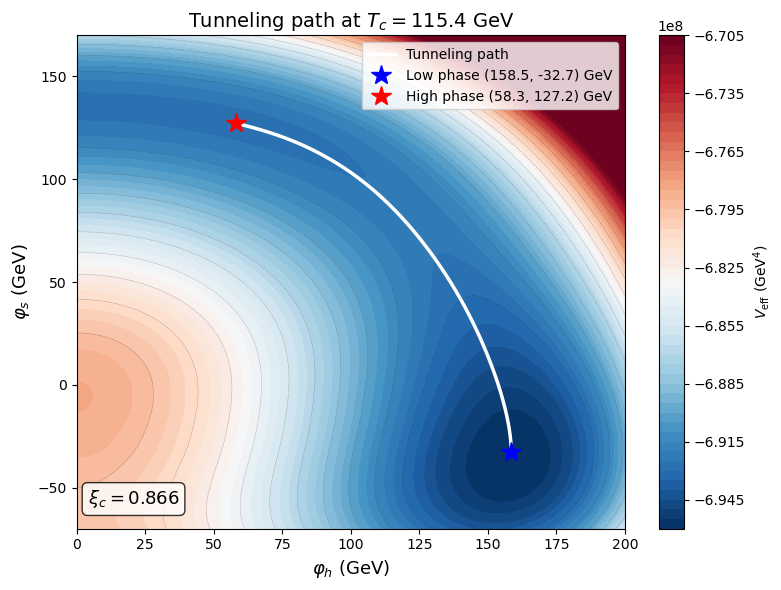

In [25]:
# Extract tunneling path
path_points = tunnel['instanton'].Phi

# Overlay on the contour plot
fig, ax = plt.subplots(figsize=(8, 6))

# Same contour as before
h_vals = np.linspace(0, 200, 300)
s_vals = np.linspace(-70, 170, 300)
H, S   = np.meshgrid(h_vals, s_vals)
X_grid = np.column_stack([H.ravel(), S.ravel()])
V_grid = model.Vtot(X_grid, Tc).reshape(H.shape)
V_plot = np.clip(V_grid, np.percentile(V_grid, 2), np.percentile(V_grid, 95))

cp = ax.contourf(H, S, V_plot, levels=60, cmap='RdBu_r')
ax.contour(H, S, V_plot, levels=20, colors='k', linewidths=0.3, alpha=0.4)
plt.colorbar(cp, ax=ax, label=r'$V_{\rm eff}$ (GeV$^4$)')

# Tunneling path
ax.plot(path_points[:, 0], path_points[:, 1], 
        'w-', linewidth=2.5, label='Tunneling path', zorder=6)
ax.plot(path_points[0, 0],  path_points[0, 1],  
        'b*', markersize=15, zorder=7,
        label=rf'Low phase ({path_points[0,0]:.1f}, {path_points[0,1]:.1f}) GeV')
ax.plot(path_points[-1, 0], path_points[-1, 1], 
        'r*', markersize=15, zorder=7,
        label=rf'High phase ({path_points[-1,0]:.1f}, {path_points[-1,1]:.1f}) GeV')

ax.set_xlabel(r'$\varphi_h$ (GeV)', fontsize=13)
ax.set_ylabel(r'$\varphi_s$ (GeV)', fontsize=13)
ax.set_title(rf'Tunneling path at $T_c = {Tc:.1f}$ GeV', fontsize=14)
ax.legend(fontsize=10, loc='upper right')
ax.text(0.02, 0.05, rf'$\xi_c = {xi_c:.3f}$', transform=ax.transAxes,
        fontsize=13, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig("EWPT_tunneling.svg")
plt.show()

In [27]:
from scipy.optimize import minimize

def V0_2d(X):
    return model.V0(np.array([[X[0], X[1]]]))[0]

# Check 1: is (v, vs) actually a local minimum?
# Evaluate gradient numerically
eps = 1e-4
dVdh = (V0_2d([v+eps, vs]) - V0_2d([v-eps, vs])) / (2*eps)
dVds = (V0_2d([v, vs+eps]) - V0_2d([v, vs-eps])) / (2*eps)
print(f"Gradient at (v, vs):")
print(f"  dV/dh = {dVdh:.6f}  (should be ~0)")
print(f"  dV/ds = {dVds:.6f}  (should be ~0)")

# Check 2: local minimizer starting exactly from (v, vs) with tight simplex
res = minimize(V0_2d, [v, vs], method='Nelder-Mead',
               options={'xatol':1e-8, 'fatol':1e-8,
                        'initial_simplex': [[v, vs],
                                            [v+1, vs],
                                            [v, vs+1]]})
print(f"\nLocal minimum near (v, vs):")
print(f"  phi_h = {res.x[0]:.4f} GeV  (expect {v})")
print(f"  phi_s = {res.x[1]:.4f} GeV  (expect {vs})")
print(f"  V0    = {res.fun:.4f} GeV^4")

# Check 3: value at the other minimum the solver found
print(f"\nValue at other minimum (0, 238):")
print(f"  V0 = {V0_2d([0, 238]):.4f} GeV^4")
print(f"Value at our minimum (v, vs):")
print(f"  V0 = {V0_2d([v, vs]):.4f} GeV^4")

Gradient at (v, vs):
  dV/dh = 0.000149  (should be ~0)
  dV/ds = -0.000149  (should be ~0)

Local minimum near (v, vs):
  phi_h = -0.0000 GeV  (expect 246.0)
  phi_s = 238.3604 GeV  (expect 30.0)
  V0    = -196959698.0719 GeV^4

Value at other minimum (0, 238):
  V0 = -519080343.6667 GeV^4
Value at our minimum (v, vs):
  V0 = -123839437.5000 GeV^4


In [29]:
# Free BSM parameters — adjusted for physical EW vacuum
lHS  = 0.25
muHS = 5.0
lS   = 0.5
mu3  = 5.0    # reduced — large mu3 creates deep singlet minimum
vs   = 50.0   # larger singlet vev

# Derived parameters
lH   = mh**2 / (2 * v**2)
muH  = np.sqrt(lH * v**2 + lHS/2 * vs**2 + muHS * vs)
muS2 = lHS/2 * v**2 + muHS * v**2/(2*vs) + lS * vs**2 - mu3 * vs

if muS2 < 0:
    print("WARNING: muS^2 < 0, choose different parameters")
else:
    muS = np.sqrt(muS2)
    print(f"lH={lH:.4f}, muH={muH:.2f}, muS={muS:.2f}")

    model = xSM(lH=lH, muH=muH, lHS=lHS, muHS=muHS,
                lS=lS, mu3=mu3, muS=muS)

    # Check all minima on a coarse grid
    from scipy.optimize import minimize
    
    def V0_2d(X):
        return model.V0(np.array([[X[0], X[1]]]))[0]

    # Scan starting points
    candidates = []
    for h0 in [0, 100, 246, -246]:
        for s0 in [-50, 0, vs, 100]:
            res = minimize(V0_2d, [h0, s0], method='Nelder-Mead',
                          options={'xatol':1e-6, 'fatol':1e-6})
            candidates.append((res.fun, res.x))

    candidates.sort(key=lambda x: x[0])
    print("\nLowest minima found:")
    for val, pos in candidates[:4]:
        print(f"  (phi_h={pos[0]:.1f}, phi_s={pos[1]:.1f})  V0={val:.1f}")

    print(f"\nEW minimum value:     {V0_2d([v, vs]):.1f}")
    print(f"Global minimum value: {candidates[0][0]:.1f}")
    print(f"EW vacuum is global minimum: {abs(candidates[0][0] - V0_2d([v,vs])) < 1.0}")

lH=0.1291, muH=91.52, muS=107.66

Lowest minima found:
  (phi_h=242.5, phi_s=-101.8)  V0=-156391129.7
  (phi_h=242.5, phi_s=-101.8)  V0=-156391129.7
  (phi_h=242.5, phi_s=-101.8)  V0=-156391129.7
  (phi_h=242.5, phi_s=-101.8)  V0=-156391129.7

EW minimum value:     -132110270.8
Global minimum value: -156391129.7
EW vacuum is global minimum: False


In [ ]:
def check_physical(vs, lHS=0.25, muHS=5.0, lS=0.5, mu3=5.0):
    lH  = mh**2 / (2 * v**2)
    muH2 = lH * v**2 + lHS/2 * vs**2 + muHS * vs
    muS2 = lHS/2 * v**2 + muHS * v**2/(2*vs) + lS * vs**2 - mu3 * vs
    
    if muH2 < 0 or muS2 < 0:
        return None, None, None
    
    muH = np.sqrt(muH2)
    muS = np.sqrt(muS2)
    m = xSM(lH=lH, muH=muH, lHS=lHS, muHS=muHS, lS=lS, mu3=mu3, muS=muS)
    
    def V0_2d(X):
        return m.V0(np.array([[X[0], X[1]]]))[0]
    
    V_ew = V0_2d([v, vs])
    
    # Check competing minima
    candidates = []
    for h0 in [0, 50, 150, 246, -246]:
        for s0 in [-100, -50, 0, vs, 100, 200]:
            res = minimize(V0_2d, [h0, s0], method='Nelder-Mead',
                          options={'xatol':1e-5, 'fatol':1e-5})
            candidates.append(res.fun)
    
    V_global = min(candidates)
    is_physical = abs(V_global - V_ew) < abs(V_ew) * 1e-3
    return is_physical, V_ew, muH, muS

# Scan vs
print("Scanning vs...")
for vs_test in np.arange(10, 150, 5):
    ok, Vew, muH, muS = check_physical(vs_test)
    if ok:
        print(f"  vs={vs_test:.0f} GeV  ->  PHYSICAL ✓  muH={muH:.2f}  muS={muS:.2f}")
    elif ok is not None:
        print(f"  vs={vs_test:.0f} GeV  ->  not global minimum")